In [1]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"

In [2]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

In [3]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

In [4]:
len(dataset)

53

In [5]:
print(velmodel.vp.min())
print(np.isnan(velmodel.vp))
print(velmodel.vp.shape)
print(model.shape)
from devito import mmin
print(mmin(model.vp))

0.5199999999999999
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
(2005, 805)
(805, 2005)
0.6000000238418579


/home/andrey/devito-vti/examples/seismic/datasets/velmodel.py:332: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.01)


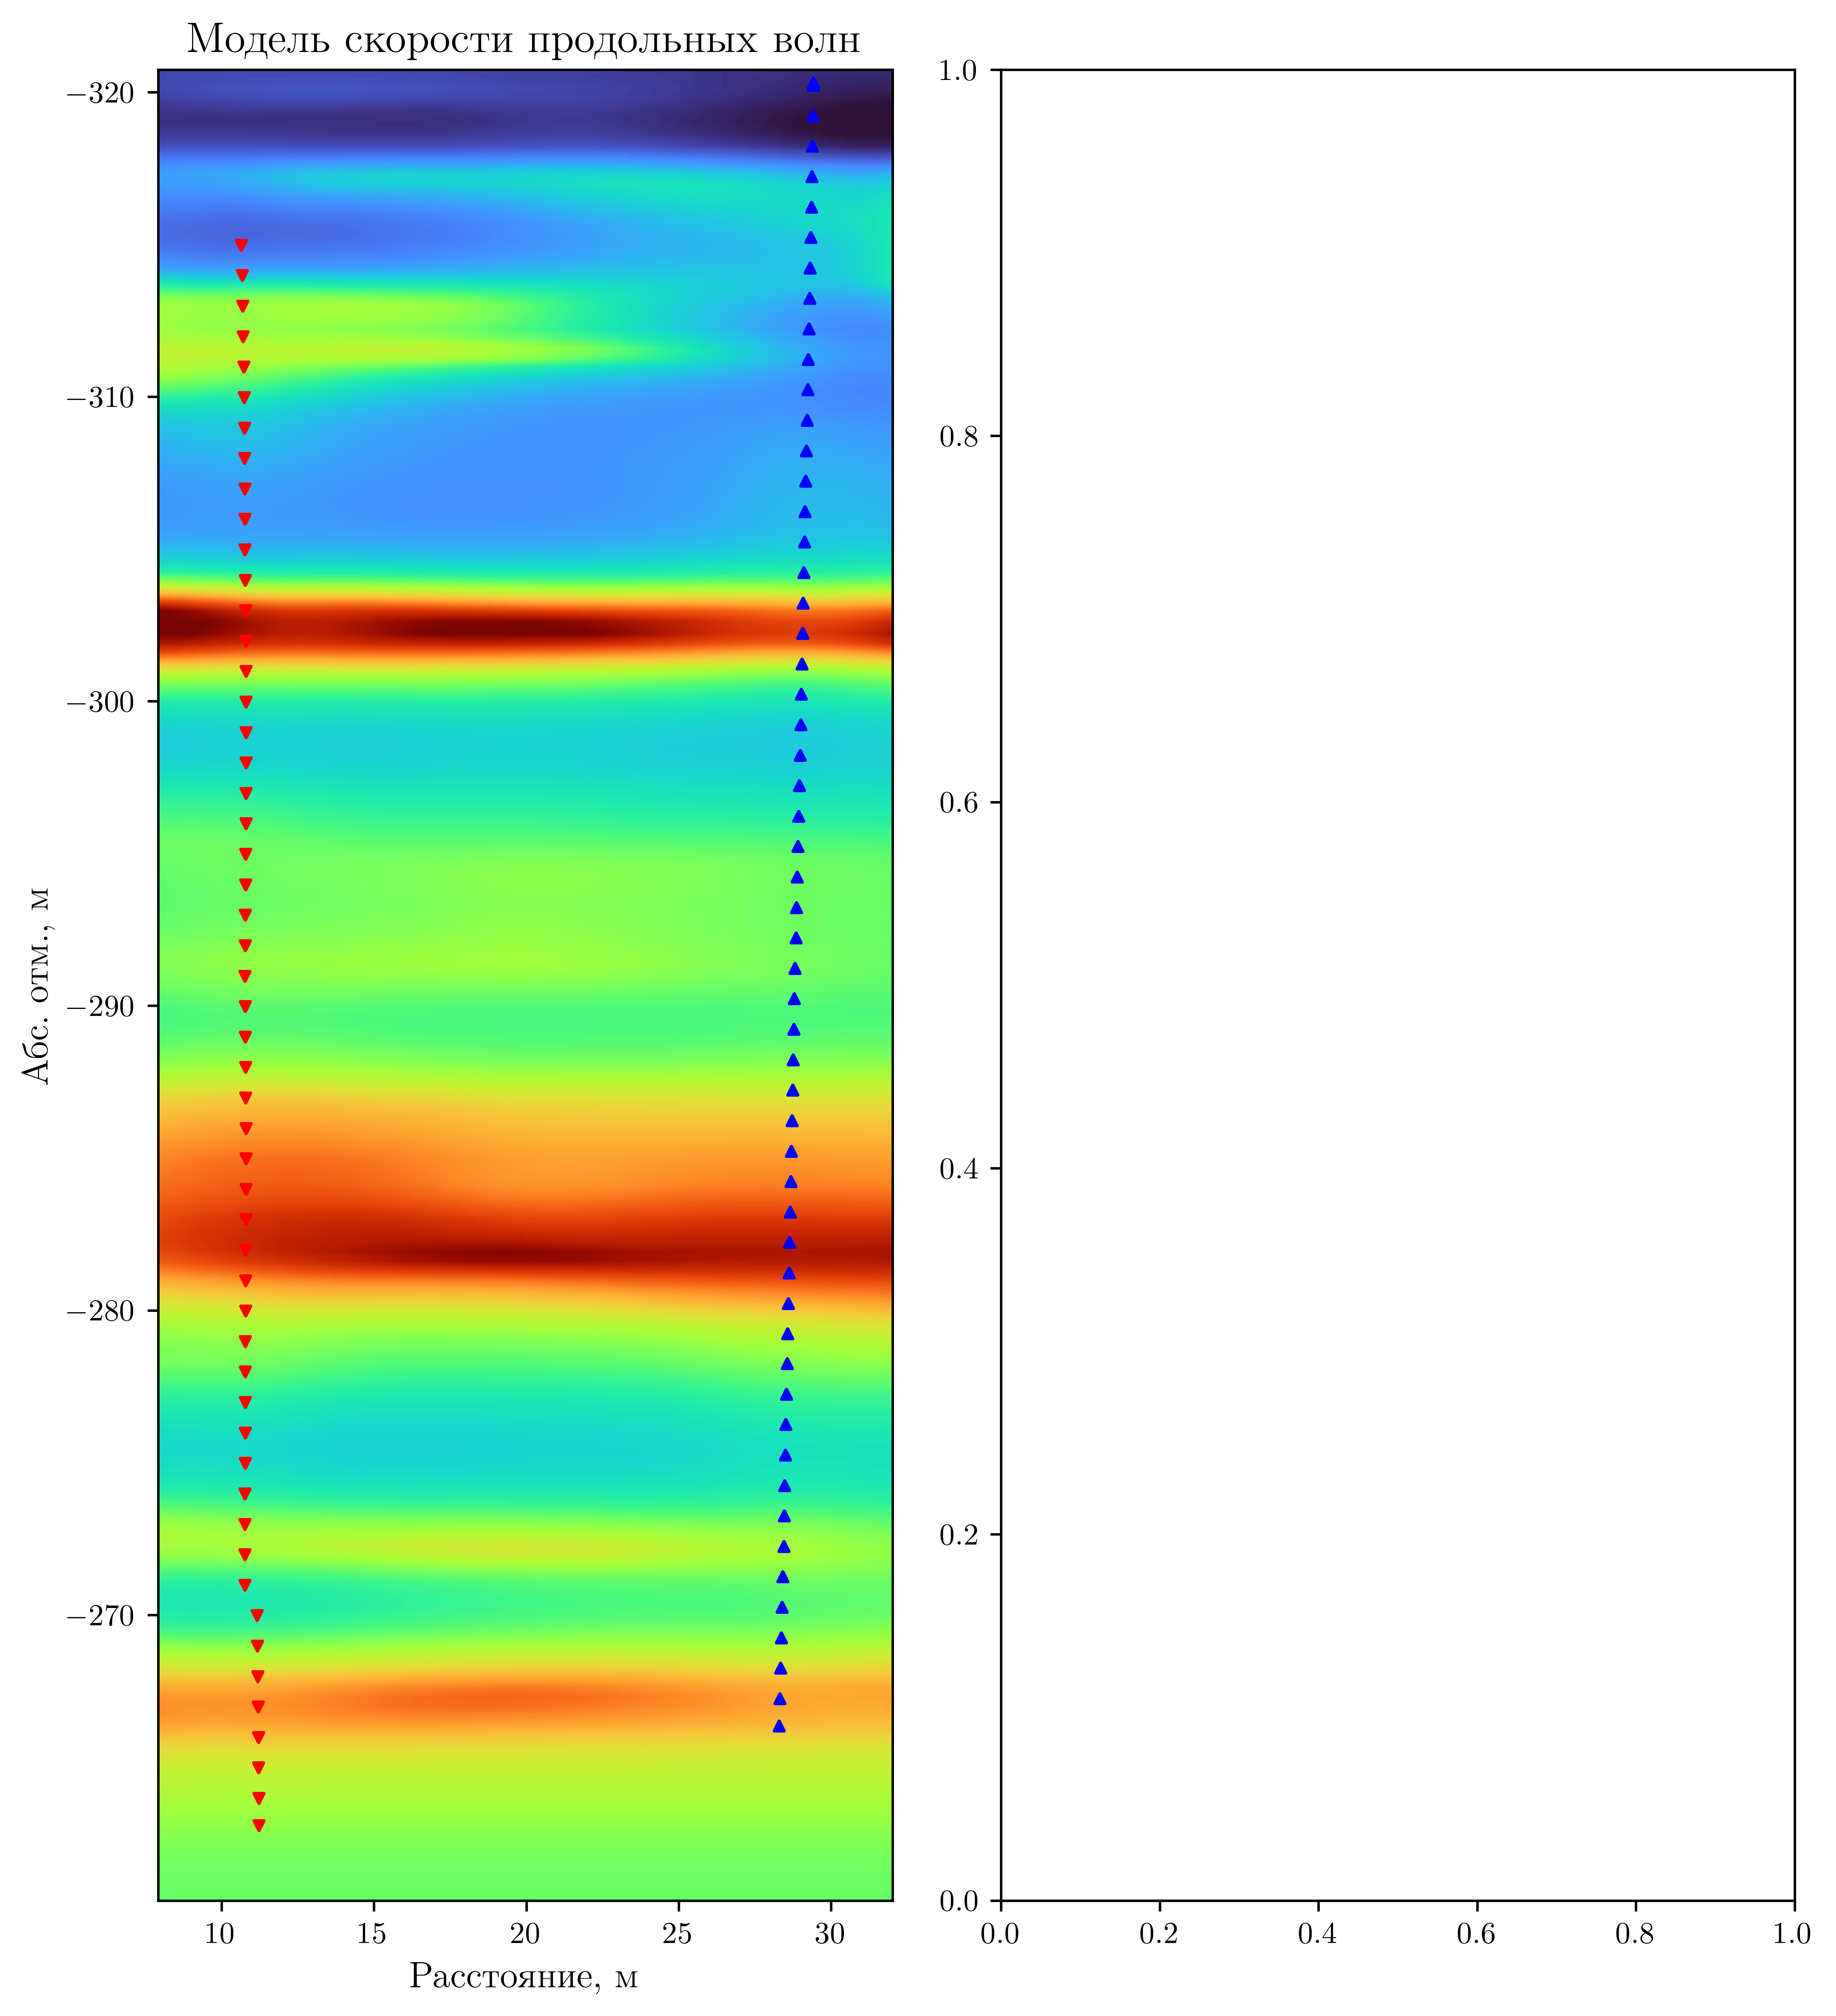

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(8.2, 9), dpi=600, constrained_layout=True)
velmodel.plot_vp(show=False, axs=axs[0])

# axs[0].imshow(layered, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)
# im1 = axs[1].imshow(layered_gal, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)

axs[0].scatter(dataset.x_coords, dataset.elevations, c='r', s=10, marker='v', zorder=50)
axs[0].scatter(dataset.opposite_x, dataset.opposite_elev, c='b', s=10, marker='^', zorder=50)


axs[0].set_xlabel("Расстояние, м")
plt.show()

In [7]:
from devito import mmin
print(velmodel.vp.min())
print(mmin(model.vp))

0.5199999999999999
0.6000000238418579


In [8]:
print(0.6/10/2000*1000)

0.03


In [9]:
print(model.critical_dt)

0.003053


In [10]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]
t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

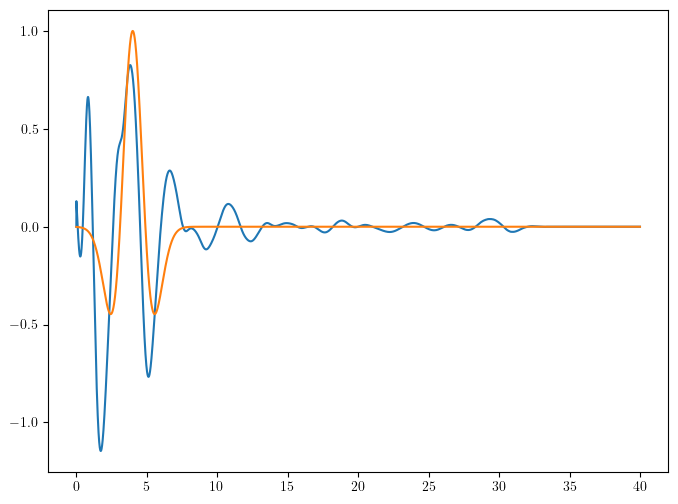

In [14]:
plt.plot(geometry.time_axis.time_values, srca.data[:]*1000)
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [15]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [16]:
500000/5000

100.0

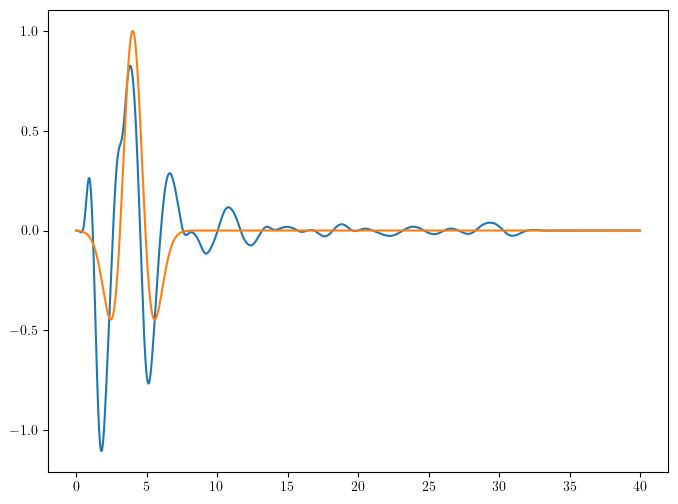

In [18]:
plt.plot(geometry.time_axis.time_values, left_taper_tukey(srca.data[:].reshape(-1)*1000, alpha=0.05)[0])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

Iter 1: Alpha = 41.88143507318896 Misfit = 8.8008e+03
Scale:  42659.39814738855 0.6880342254429913 0.610595452818171
Iter 2: Alpha = 30.709077991516768 Misfit = 5.4227e+03
Scale:  48598.757908602536 0.6880342254429913 0.5498615714814128
Iter 3: Alpha = 34.584405045960494 Misfit = 3.7571e+03
Scale:  50310.96642826425 0.6880342254429913 0.5889022347436803
Iter 4: Alpha = 20.56479784863832 Misfit = 2.3729e+03


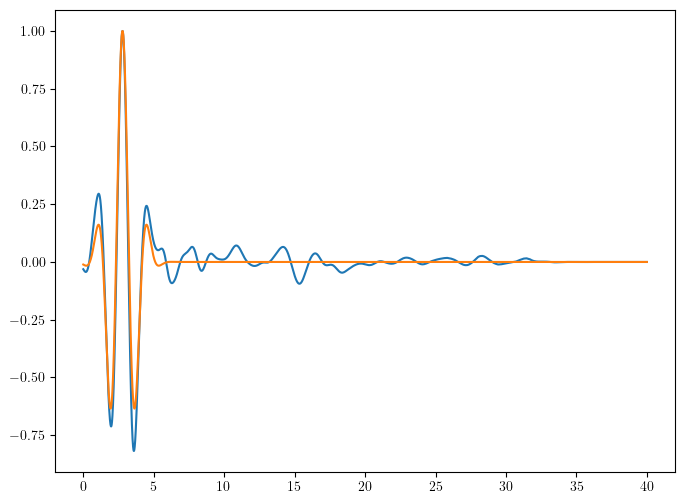

48. Estimated gather centroid frequency: 502.09 Hz, Wavelet length: 1.99 ms
Scale:  28005.6319970841 0.6666764662467076 0.7224817300599341
Iter 0: Alpha = 251.2152044453581 Misfit = 8.3017e+04
Scale:  39611.57888295405 0.6666764662467076 0.4518615964149499
Iter 1: Alpha = 34.21520730016241 Misfit = 1.1485e+04
Scale:  48183.83847647422 0.6666764662467076 0.6212327650494847
Iter 2: Alpha = 49.37264960606111 Misfit = 8.1806e+03
Scale:  45434.982657284134 0.6666764662467076 0.4676328882943204
Iter 3: Alpha = 20.735068774166805 Misfit = 5.1348e+03
Scale:  61678.08311716744 0.6666764662467076 0.6635573830350439
Iter 4: Alpha = 103.89168389839203 Misfit = 3.9891e+03


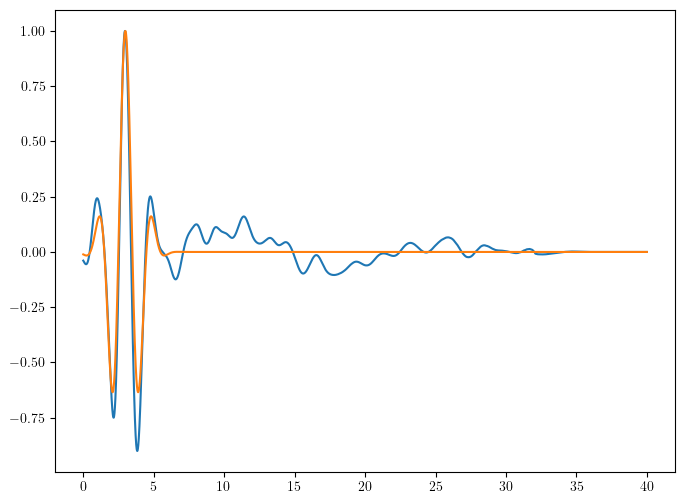

49. Estimated gather centroid frequency: 483.41 Hz, Wavelet length: 2.07 ms
Scale:  29443.124059183683 0.5818213667111561 0.6740563895908277
Iter 0: Alpha = 282.65783717196706 Misfit = 8.9674e+04
Scale:  36622.33479649105 0.5818213667111561 0.3957724706742437
Iter 1: Alpha = 34.100883342616015 Misfit = 1.6879e+04
Scale:  48106.40339354789 0.5818213667111561 0.5709429402221505
Iter 2: Alpha = 93.85041465337444 Misfit = 1.3035e+04
Scale:  38938.65996792836 0.5818213667111561 0.37670072461529075
Iter 3: Alpha = 19.468135534611488 Misfit = 6.8437e+03
Scale:  60963.15776979694 0.5818213667111561 0.6119948230469533
Iter 4: Alpha = 94.08647915187181 Misfit = 5.5767e+03


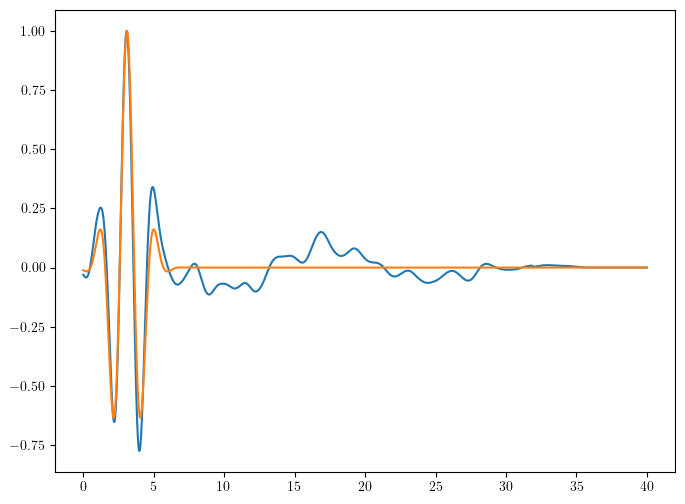

50. Estimated gather centroid frequency: 461.58 Hz, Wavelet length: 2.17 ms
Scale:  23345.979970962046 0.44991878658519374 0.514042848984576
Iter 0: Alpha = 391.3545053534272 Misfit = 9.8522e+04
Scale:  27320.61817158463 0.44991878658519374 0.2971960826227263
Iter 1: Alpha = 44.151909611007866 Misfit = 2.1203e+04
Scale:  37767.78363307246 0.44991878658519374 0.43506553027817896
Iter 2: Alpha = 193.90053258485614 Misfit = 1.6932e+04
Scale:  31123.729228068292 0.44991878658519374 0.3122264961864907
Iter 3: Alpha = 27.82291666120819 Misfit = 6.9147e+03
Scale:  48694.97980618238 0.44991878658519374 0.4981192197999297
Iter 4: Alpha = 102.45653321272214 Misfit = 5.6514e+03


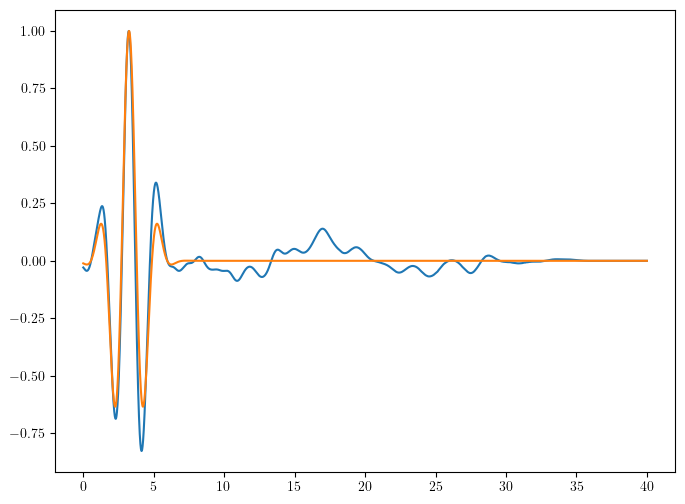

51. Estimated gather centroid frequency: 529.35 Hz, Wavelet length: 1.89 ms
Scale:  24479.9503624858 0.3856667764225131 0.4567419277309472
Iter 0: Alpha = 530.9829976247357 Misfit = 7.4977e+04
Scale:  24960.13431158555 0.3856667764225131 0.24706371594000026
Iter 1: Alpha = 41.85008823687419 Misfit = 1.5602e+04
Scale:  37502.097684053115 0.3856667764225131 0.3226352009609529
Iter 2: Alpha = 150.75872563247748 Misfit = 1.2864e+04
Scale:  34154.736152456055 0.3856667764225131 0.405315791976485
Iter 3: Alpha = 42.51286784750283 Misfit = 7.7684e+03
Scale:  46472.544191432695 0.3856667764225131 0.42905116629616674
Iter 4: Alpha = 249.78193529626088 Misfit = 6.5643e+03


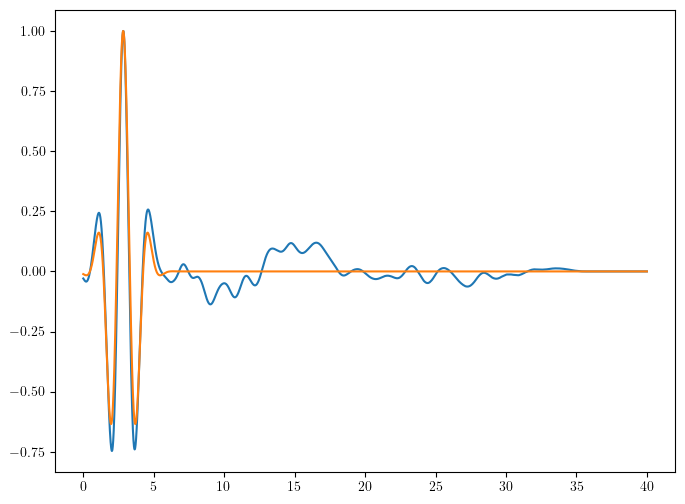

52. Estimated gather centroid frequency: 471.28 Hz, Wavelet length: 2.12 ms
Scale:  8931.722033830156 0.1411504476472936 0.17337479198863448
Iter 0: Alpha = 1232.1752648845893 Misfit = 9.4750e+04
Scale:  9195.565142180209 0.1411504476472936 0.0954442565696043
Iter 1: Alpha = 134.90719717330643 Misfit = 2.3958e+04
Scale:  13693.891645545047 0.1411504476472936 0.14115377229689696
Iter 2: Alpha = 702.0031057480736 Misfit = 1.9872e+04
Scale:  11798.547312863606 0.1411504476472936 0.15544894382523455
Iter 3: Alpha = 131.86080300883853 Misfit = 9.7160e+03
Scale:  17121.33054610406 0.1411504476472936 0.17532074197657138
Iter 4: Alpha = 587.0958943434825 Misfit = 8.1292e+03


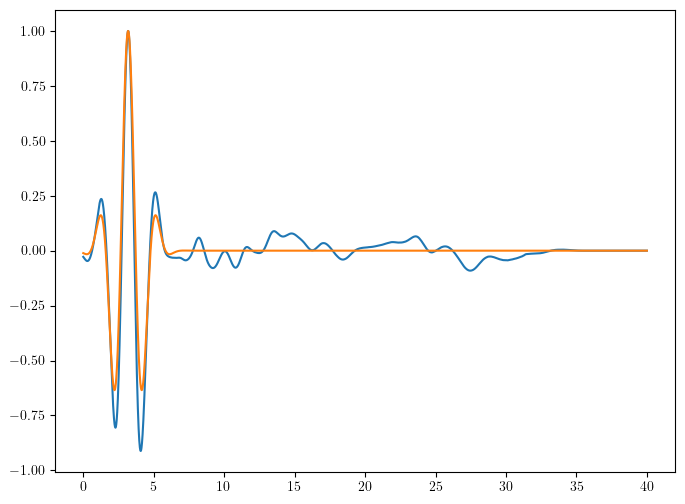

In [21]:
max_iter = 5
beta = 2e-4
for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"{k}. Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = AcousticWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.995), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.995))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Alpha = {alpha} Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"../adjoint_wavelets/wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"../adjoint_wavelets/wavelet_scale_{k}.npy", scale_factor)